# 📈 Regressão Linear Simples: Ajuste Analítico e Otimização Iterativa

Este notebook apresenta o estudo conceitual, matemático e prático da **Regressão Linear Simples** desenvolvida do zero. 
Abordaremos duas vertentes clássicas para a calibração de pesos:
1. **Método Analítico (Mínimos Quadrados Otimizados - MQO)**: A solução analítica exata baseada em covariâncias e médias.
2. **Método Iterativo (Gradiente Descendente - GD)**: O algoritmo de otimização clássico usado no aprendizado profundo, calibrando os coeficientes passo a passo.

Consumiremos nossa biblioteca estatística local `estatistica as est` e de machine learning `machine_learning as ml`.

In [1]:
# Importando bibliotecas de visualização e suporte
import matplotlib.pyplot as plt
import seaborn as sns

# Importando as funções desenvolvidas dos nossos arquivos locais
import estatistica as est
import machine_learning as ml

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Regressão Linear Simples via Mínimos Quadrados Otimizados (MQO)

A abordagem analítica clássica calcula os coeficientes angular ($\beta_1$ ou $a$) e linear ($\beta_0$ ou $b$) minimizando a soma dos erros quadráticos com base nas médias amostrais, variâncias e covariâncias:

$$\beta_1 = a = \frac{\text{Covariance}(X, Y)}{\text{Variance}(X)} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

$$\beta_0 = b = \bar{y} - a \cdot \bar{x}$$

Vamos aplicar essa calibração analítica a um conjunto de dados de exemplo relacionando horas de estudo à nota do aluno.

=== MÉTODO ANALÍTICO (MQO) ===
Média de Horas (x): 6.17 | Variância de x: 12.1667
Média de Notas (y): 7.02 | Covariância XY: 7.3967

Coeficiente Angular (a): 0.607945
Coeficiente Linear (b):  3.267671


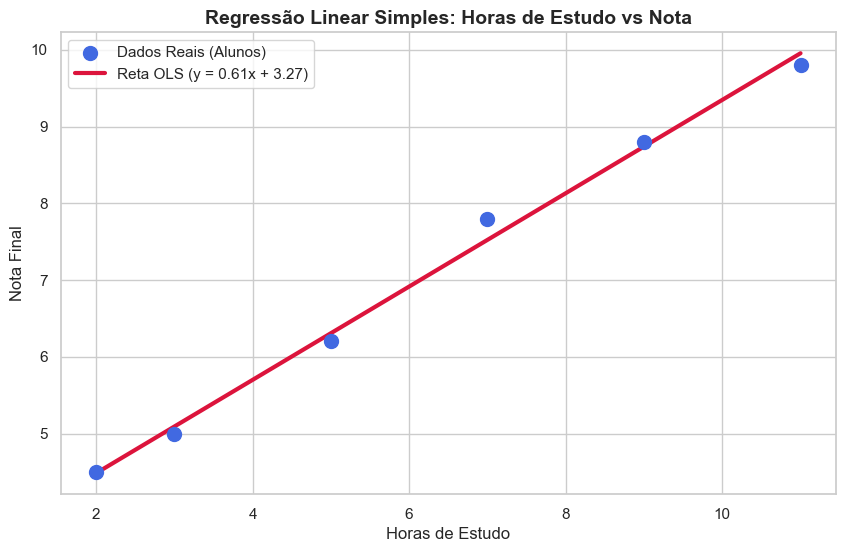

In [2]:
# Dados de exemplo
horas_estudo = [2, 3, 5, 7, 9, 11]
notas = [4.5, 5.0, 6.2, 7.8, 8.8, 9.8]

# Executando a calibração analítica (MQO)
passo_angular, passo_linear = ml.minimos_quadrados(horas_estudo, notas)

# Gerando as previsões
y_predito = ml.realizar_previsao(horas_estudo, passo_angular, passo_linear)

print("=== MÉTODO ANALÍTICO (MQO) ===")
print(f"Média de Horas (x): {est.media(horas_estudo):.2f} | Variância de x: {est.variancia(horas_estudo):.4f}")
print(f"Média de Notas (y): {est.media(notas):.2f} | Covariância XY: {est.covariancia(horas_estudo, notas):.4f}")
print(f"\nCoeficiente Angular (a): {passo_angular:.6f}")
print(f"Coeficiente Linear (b):  {passo_linear:.6f}")

# Plotando a dispersão e reta ideal de mínimos quadrados
plt.scatter(horas_estudo, notas, color='royalblue', s=100, label='Dados Reais (Alunos)', zorder=3)
plt.plot(horas_estudo, y_predito, color='crimson', linewidth=3, 
         label=f'Reta OLS (y = {passo_angular:.2f}x + {passo_linear:.2f})', zorder=2)
plt.title('Regressão Linear Simples: Horas de Estudo vs Nota', fontsize=14, fontweight='bold')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota Final')
plt.legend(loc='upper left')
plt.show()

--- 
## 2. Otimização Iterativa via Gradiente Descendente (GD)

Diferente da solução direta, o **Gradiente Descendente** calibra os coeficientes iterativamente dando passos na direção oposta à inclinação da função de custo (MSE):

$$b \leftarrow b - \alpha \left(-\frac{2}{n} \sum_{i=1}^n (y_i - y_{\text{pred}})\right)$$

$$a \leftarrow a - \alpha \left(-\frac{2}{n} \sum_{i=1}^n (y_i - y_{\text{pred}})x_i\right)$$

Onde $\alpha$ é a **taxa de aprendizado**. O modelo começa com os pesos zerados ($a=0, b=0$) e vai se corrigindo ao longo das épocas. 

Abaixo, plotamos a convergência das variáveis e destacamos o quão distantes elas estavam do ideal pré-calculado pelo OLS a cada iteração!

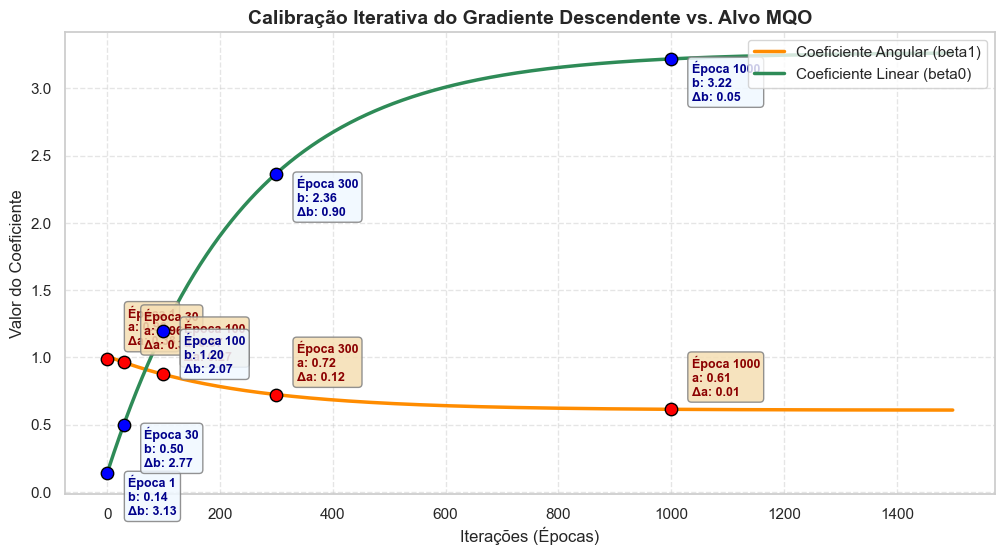

In [6]:
# Simulando a convergência iterativa
historico_angular = []
historico_linear = []

c_linear, c_angular = 0.0, 0.0
taxa_aprendizado = 0.01
epocas = 1500

for _ in range(epocas):
    c_linear, c_angular = ml.gradient_descent(horas_estudo, notas, taxa_aprendizado, c_linear, c_angular)
    historico_angular.append(c_angular)
    historico_linear.append(c_linear)

# Curva de convergência detalhada com pontos de destaque
plt.figure(figsize=(12, 6))
plt.plot(historico_angular, label=r'Coeficiente Angular (beta1)', color='darkorange', lw=2.5)
plt.plot(historico_linear, label=r'Coeficiente Linear (beta0)', color='seagreen', lw=2.5)

# Definindo iterações chaves para evidenciar o aprendizado
it_destaque = [1, 30, 100, 300, 1000]

for it in it_destaque:
    idx = it - 1  # Indice 0
    val_a = historico_angular[idx]
    val_b = historico_linear[idx]
    
    # Distância em relação à solução ideal analítica do MQO
    delta_a = abs(val_a - passo_angular)
    delta_b = abs(val_b - passo_linear)
    
    # Adicionando bolinhas nas curvas nos pontos correspondentes
    plt.scatter(idx, val_a, color='red', s=80, zorder=5, edgecolors='black')
    plt.scatter(idx, val_b, color='blue', s=80, zorder=5, edgecolors='black')
    
    # Anotação de progresso e distância para a curva Angular (a)
    plt.annotate(
        f"Época {it}\na: {val_a:.2f}\nΔa: {delta_a:.2f}",
        xy=(idx, val_a),
        textcoords="offset points",
        xytext=(15, 10),
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='darkred',
        bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.85, ec="gray")
    )
    
    # Anotação de progresso e distância para a curva Linear (b)
    plt.annotate(
        f"Época {it}\nb: {val_b:.2f}\nΔb: {delta_b:.2f}",
        xy=(idx, val_b),
        textcoords="offset points",
        xytext=(15, -30),
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='darkblue',
        bbox=dict(boxstyle="round,pad=0.3", fc="aliceblue", alpha=0.85, ec="gray")
    )

plt.title('Calibração Iterativa do Gradiente Descendente vs. Alvo MQO', fontsize=14, fontweight='bold')
plt.xlabel('Iterações (Épocas)')
plt.ylabel('Valor do Coeficiente')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- 
## 3. Avaliação de Performance e Análise de Resíduos

Para validar o modelo de regressão simples, calculamos as métricas de erro ($RMSE$, $MSE$, $\text{Erro Percentual}$) e analisamos o comportamento dos resíduos (erros ponto a ponto).

O ideal é que os resíduos se distribuam aleatoriamente em torno de zero, sem formar um padrão visível.

=== MÉTRICAS DE AJUSTE (REGRESSÃO SIMPLES) ===
  - RMSE: 0.144045
  - MSE: 0.020749
  - Erro Percentual Médio: 2.052893


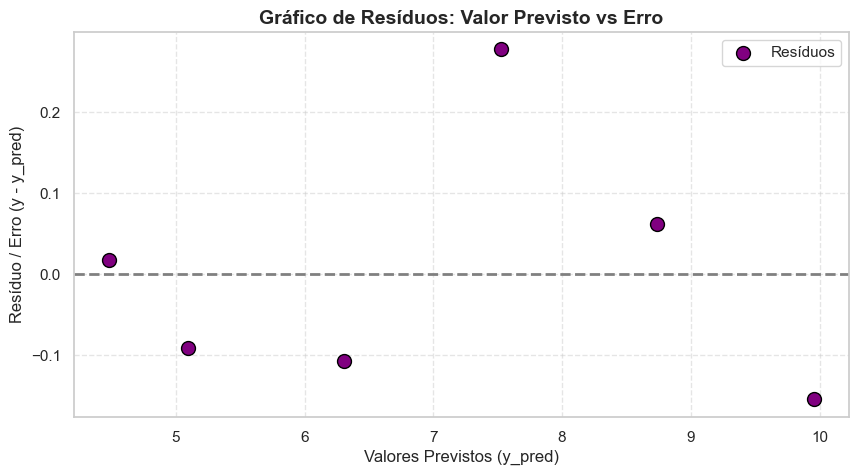

In [7]:
# Previsões finais do MQO
y_predito_final = ml.realizar_previsao(horas_estudo, passo_angular, passo_linear)

# Calculando métricas de erro usando a biblioteca
metricas = ml.rmse(notas, y_predito_final)
print("=== MÉTRICAS DE AJUSTE (REGRESSÃO SIMPLES) ===")
for k, v in metricas.items():
    print(f"  - {k}: {v:.6f}")

# Calculando os erros ponto a ponto (resíduos)
residuos = ml.calcular_erro(notas, y_predito_final)

# Plotando o gráfico de resíduos
plt.figure(figsize=(10, 5))
plt.scatter(y_predito_final, residuos, color='purple', s=100, edgecolors='black', label='Resíduos')
plt.axhline(y=0.0, color='gray', linestyle='--', linewidth=2)
plt.title('Gráfico de Resíduos: Valor Previsto vs Erro', fontsize=14, fontweight='bold')
plt.xlabel('Valores Previstos (y_pred)')
plt.ylabel('Resíduo / Erro (y - y_pred)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()